#### Supp. Fig 3f

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import scanpy as sc  
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl 
import cell2location 
import pandas as pd
import seaborn as sns  
import pandas as pd  
import random
import statsmodels.api as sm
pd.set_option('display.max_columns',400)
pd.set_option('display.max_categories',40)
# Set general parameters for publication-ready figures
plt.rcParams.update({
    'pdf.fonttype': 42,
    'font.family': 'Arial',  # Set font to Arial
    'font.size': 14,  # Set font size to at least 14
    'axes.labelsize': 14,  # Axes labels size
    'axes.titlesize': 16,  # Title size for axes
    'xtick.labelsize': 14,  # X-tick label size
    'ytick.labelsize': 14,  # Y-tick label size
    'legend.fontsize': 14,  # Legend font size
    'figure.titlesize': 16,  # Figure title size
    'lines.linewidth': 2,  # Line width for clarity
    'axes.linewidth': 1.5,  # Axis line width
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'text.color': 'black',  # Make sure text is black (not grey)
    'axes.labelcolor': 'black',  # Ensure axes labels are black
    'axes.edgecolor': 'black',  # Ensure edge of axes is black
    'xtick.color': 'black',  # Ensure X-tick marks are black
    'ytick.color': 'black',  # Ensure Y-tick marks are black
    'axes.titlepad': 20  # Padding for title

})

save_dir = "fig"
# Create the directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

boxprops=dict(edgecolor="black")
whiskerprops=dict(color="black")
capprops=dict(color='black')
medianprops=dict(color='black')



In [3]:
ann_finest_level = pd.read_excel("/Users/jk/Documents/Lab2/visium/python_analysis/local_401/exploratory/boxplot_normalized_to_total_cell_abundance_ann_finest_level/ann_finest_level_abs_cell_count.xlsx",
                                 index_col=0)

In [4]:
Banovich_Kropski_2020 = pd.read_excel("/Users/jk/Documents/Lab2/visium/python_analysis/local_401/exploratory/boxplot_normalized_to_total_cell_abundance_Banovich_Kropski_2020/Banovich_Kropski_2020_abs_cell_count.xlsx",
                                      index_col=0)

In [5]:
ann_finest_level.shape

(160702, 31)

In [6]:
Banovich_Kropski_2020.shape

(160702, 31)

In [7]:
full_corr = pd.DataFrame(index=ann_finest_level.columns, columns=Banovich_Kropski_2020.columns)


In [8]:
full_corr.shape

(31, 31)

In [9]:
ann_finest_level.columns

Index(['AT0', 'AT1', 'AT2', 'Adventitial fibroblasts', 'Alveolar Mph CCL3+',
       'Alveolar fibroblasts', 'Alveolar macrophages', 'B cells',
       'CD4 T cells', 'CD8 T cells', 'EC aerocyte capillary', 'EC arterial',
       'EC general capillary', 'EC venous pulmonary', 'EC venous systemic',
       'Interstitial Mph perivascular', 'Lymphatic EC differentiating',
       'Lymphatic EC mature', 'Mast cells', 'Monocyte-derived Mph',
       'Multiciliated (non-nasal)', 'Myofibroblasts', 'NK cells',
       'Peribronchial fibroblasts', 'Pericytes', 'Plasma cells',
       'Smooth muscle', 'Smooth muscle FAM83D+', 'Subpleural fibroblasts',
       'T cells proliferating', 'pre-TB secretory'],
      dtype='object')

In [22]:
ann_finest_level['Plasma cells'].corr(Banovich_Kropski_2020['Plasma Cells'])

0.9541734089184544

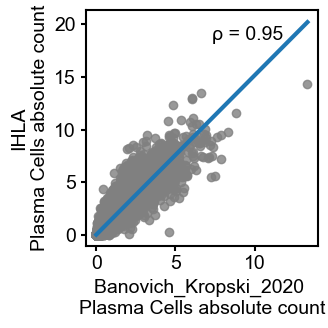

In [29]:
fig, ax = plt.subplots(1,1, figsize = (3.5, 3.5))
sns.regplot(y= ann_finest_level['Plasma cells'], x= Banovich_Kropski_2020["Plasma Cells"], ax = ax, scatter_kws = {"color":"grey"})

ax.set_ylabel("IHLA\nPlasma Cells absolute count")
ax.set_xlabel("Banovich_Kropski_2020 \nPlasma Cells absolute count")
# --- Add text box in top-right ---
ax.text(
    0.85,              # x position in axis coords (0–1)
    0.93,              # y position in axis coords
    "ρ = 0.95",       # text
    ha="right", va="top",
    transform=ax.transAxes,
    fontsize=14,
    #bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8)
)
plt.tight_layout()
plt.savefig(os.path.join(save_dir,"xy_plasma_cells.pdf"), bbox_inches = "tight", transparent= True)
plt.show()

In [ ]:
# full pairwise correlation:
full_corr = pd.DataFrame(index=ann_finest_level.columns, columns=Banovich_Kropski_2020.columns)

for col1 in ann_finest_level.columns:
    for col2 in Banovich_Kropski_2020.columns:
        full_corr.loc[col1, col2] = ann_finest_level[col1].corr(Banovich_Kropski_2020[col2])

# Convert to float (the above is object type by default)
full_corr = full_corr.astype(float)

In [9]:
full_corr

,AT1,AT2,B Cells,Basal,Ciliated,Differentiating Ciliated,Endothelial Cells,Fibroblasts,HAS1 High Fibroblasts,KRT5-/KRT17+,Lymphatic Endothelial Cells,MUC5AC+ High,MUC5B+,Macrophages,Mast Cells,Mesothelial Cells,Monocytes,Myofibroblasts,NK Cells,PLIN2+ Fibroblasts,Plasma Cells,Proliferating Epithelial Cells,Proliferating Macrophages,Proliferating T Cells,SCGB3A2+,SCGB3A2+ SCGB1A1+,Smooth Muscle Cells,T Cells,Transitional AT2,cDCs,pDCs
AT0,0.243003,0.151885,-0.015076,0.388298,0.136122,0.075607,0.010947,-0.103477,0.032269,0.087729,-0.080991,0.010203,0.008614,0.019751,0.031635,-0.003756,0.000218,-0.028439,0.020780,-0.026725,-0.053556,0.328592,0.051864,0.029375,0.829126,0.236726,-0.094982,0.020204,0.277721,0.123659,0.005091
AT1,0.905240,0.544659,-0.065936,-0.028607,-0.081945,-0.098438,0.489825,-0.188015,0.034843,0.183003,-0.125805,-0.048019,-0.085041,0.220266,0.112606,-0.038581,0.125698,0.174423,0.231142,-0.099482,-0.196410,0.128026,0.383954,-0.073413,0.100374,-0.038786,-0.140694,0.126584,0.608774,0.179457,-0.040423
AT2,0.538718,0.952316,-0.060233,-0.075013,-0.102524,-0.113034,0.338177,-0.138989,0.028966,0.080618,-0.119877,-0.031396,-0.082549,0.193294,0.155650,-0.035758,0.124014,0.148771,0.177247,-0.039688,-0.119675,0.076189,0.352195,-0.090925,0.008171,-0.053702,-0.155404,0.099170,0.469920,0.192142,-0.028080
Adventitial fibroblasts,-0.184244,-0.133417,-0.010054,-0.065303,-0.054940,-0.050267,-0.008976,0.890686,-0.017873,-0.079258,0.332980,-0.049776,-0.046292,-0.103065,0.068920,0.149118,-0.016190,0.007240,-0.058558,0.488980,0.117898,-0.058817,-0.081282,-0.072285,-0.058114,-0.035487,0.148648,-0.053975,-0.092611,-0.037459,0.033083
Alveolar Mph CCL3+,0.248243,0.269148,-0.032520,-0.036835,-0.022800,-0.054142,0.093822,-0.123046,0.022956,0.073720,-0.105400,-0.008022,-0.028944,0.587656,-0.002386,-0.016762,0.235305,0.010383,0.136604,-0.014077,-0.097883,0.015501,0.404795,-0.014158,0.022557,-0.012898,-0.113762,0.124978,0.233599,0.145249,-0.046846
Alveolar fibroblasts,0.155197,0.129886,0.017733,-0.076846,-0.106749,-0.093609,0.400553,0.392058,-0.105786,-0.066536,0.363347,-0.082856,-0.080427,-0.014900,0.557011,-0.003803,0.058621,0.645092,0.197541,0.157306,0.265041,-0.054370,0.101657,-0.014247,-0.065367,-0.052552,0.264394,0.108727,0.047963,0.101190,0.218814
Alveolar macrophages,0.364045,0.320837,-0.048854,-0.085735,-0.059331,-0.068169,0.223020,-0.130552,-0.041609,-0.004970,-0.106300,-0.040392,-0.057240,0.752445,0.030109,-0.036556,0.098321,0.027365,0.127513,-0.064117,-0.137406,-0.037195,0.643853,-0.128254,-0.048932,-0.036224,-0.118542,0.064315,0.177966,0.011984,-0.067259
B cells,-0.083365,-0.073633,0.957110,-0.006788,-0.022717,-0.009929,-0.035902,0.006567,-0.018301,-0.017347,0.048752,-0.010264,-0.016197,-0.052941,0.025712,0.012656,-0.005737,-0.001540,0.058389,0.054081,0.160153,-0.019024,-0.059058,0.358369,-0.015727,-0.012723,-0.028635,0.197834,-0.043177,0.040674,0.262833
CD4 T cells,-0.017541,-0.020009,0.375310,-0.036224,-0.055110,-0.044850,0.026204,-0.016074,-0.003008,0.000688,0.054071,-0.028437,-0.044116,-0.001251,0.061262,0.005966,0.199266,0.055799,0.331929,0.102799,0.210422,-0.040997,-0.038909,0.488397,-0.030539,-0.027233,-0.089802,0.861272,0.000936,0.317023,0.341026
CD8 T cells,0.181868,0.135158,0.129950,-0.058523,-0.078210,-0.073419,0.183871,-0.027217,-0.021189,0.015888,0.034125,-0.039063,-0.063274,0.103142,0.116298,-0.004550,0.300450,0.134893,0.616435,0.073065,0.138739,-0.038101,0.082065,0.367751,-0.034428,-0.035179,-0.091047,0.679142,0.106425,0.344157,0.297529


In [10]:
ann_finest_level_ct_dict = {
    "Epithelial" : ["AT0", "AT1", "AT2", "Multiciliated (non-nasal)", "pre-TB secretory"],
    "Stroma" : ["Adventitial fibroblasts","Alveolar fibroblasts", "Myofibroblasts", "Peribronchial fibroblasts", "Pericytes",
                "Smooth muscle", "Smooth muscle FAM83D+", "Subpleural fibroblasts"],
    "Immune" : ["Alveolar Mph CCL3+","Alveolar macrophages",  "Interstitial Mph perivascular", "Monocyte-derived Mph","Mast cells",  "NK cells", "B cells","Plasma cells",  "CD4 T cells",
                "CD8 T cells","T cells proliferating"],
    "Endothelial" : ["EC aerocyte capillary", "EC arterial", "EC general capillary", "EC venous pulmonary", 
                     "EC venous systemic", "Lymphatic EC differentiating", "Lymphatic EC mature"]

}

In [11]:
ann_finest_level_ct_order = [celltype for group in ann_finest_level_ct_dict.values() for celltype in group]

In [12]:
Banovich_Kropski_2020_ct_dict = {
    "Epithelial" : [ "AT1", "AT2", 'Transitional AT2', 'Basal','Ciliated', #'Differentiating Ciliated','Proliferating Epithelial Cells',
                     'SCGB3A2+',#'SCGB3A2+ SCGB1A1+', 
                     'Smooth Muscle Cells','Mesothelial Cells'  ,'MUC5AC+ High', 'MUC5B+'  ],
    "Stroma" : ['Fibroblasts', #'HAS1 High Fibroblasts',
                 'KRT5-/KRT17+',
                'Myofibroblasts','PLIN2+ Fibroblasts'  ],
    "Immune" : ['Macrophages','Proliferating Macrophages','Monocytes','Mast Cells' ,'NK Cells','B Cells','Plasma Cells' ,'cDCs','pDCs','T Cells' ,'Proliferating T Cells',],
    "Endothelial" : ['Endothelial Cells', 'Lymphatic Endothelial Cells' ]

}

In [13]:
Banovich_Kropski_2020_ct_order = [celltype for group in Banovich_Kropski_2020_ct_dict.values() for celltype in group]

In [14]:
full_corr.loc[ann_finest_level_ct_order , Banovich_Kropski_2020_ct_order ]

,AT1,AT2,Transitional AT2,Basal,Ciliated,SCGB3A2+,Smooth Muscle Cells,Mesothelial Cells,MUC5AC+ High,MUC5B+,Fibroblasts,KRT5-/KRT17+,Myofibroblasts,PLIN2+ Fibroblasts,Macrophages,Proliferating Macrophages,Monocytes,Mast Cells,NK Cells,B Cells,Plasma Cells,cDCs,pDCs,T Cells,Proliferating T Cells,Endothelial Cells,Lymphatic Endothelial Cells
AT0,0.243003,0.151885,0.277721,0.388298,0.136122,0.829126,-0.094982,-0.003756,0.010203,0.008614,-0.103477,0.087729,-0.028439,-0.026725,0.019751,0.051864,0.000218,0.031635,0.020780,-0.015076,-0.053556,0.123659,0.005091,0.020204,0.029375,0.010947,-0.080991
AT1,0.905240,0.544659,0.608774,-0.028607,-0.081945,0.100374,-0.140694,-0.038581,-0.048019,-0.085041,-0.188015,0.183003,0.174423,-0.099482,0.220266,0.383954,0.125698,0.112606,0.231142,-0.065936,-0.196410,0.179457,-0.040423,0.126584,-0.073413,0.489825,-0.125805
AT2,0.538718,0.952316,0.469920,-0.075013,-0.102524,0.008171,-0.155404,-0.035758,-0.031396,-0.082549,-0.138989,0.080618,0.148771,-0.039688,0.193294,0.352195,0.124014,0.155650,0.177247,-0.060233,-0.119675,0.192142,-0.028080,0.099170,-0.090925,0.338177,-0.119877
Multiciliated (non-nasal),-0.096852,-0.128508,-0.072118,0.250157,0.916062,0.144378,-0.050141,0.001269,0.257803,0.310507,-0.082686,-0.011371,-0.122352,-0.015334,-0.058743,-0.062676,-0.054829,-0.045751,-0.089776,-0.017957,-0.022190,0.025631,-0.016172,-0.063010,0.005917,-0.153984,-0.065477
pre-TB secretory,-0.087237,-0.131917,-0.050765,0.528896,0.456234,0.577597,-0.064208,0.003653,0.144330,0.506952,-0.093230,0.066111,-0.113380,0.002545,-0.058345,-0.073254,-0.050433,-0.036115,-0.084235,-0.007373,0.010058,0.087866,0.006921,-0.053629,0.033541,-0.166402,-0.073591
Adventitial fibroblasts,-0.184244,-0.133417,-0.092611,-0.065303,-0.054940,-0.058114,0.148648,0.149118,-0.049776,-0.046292,0.890686,-0.079258,0.007240,0.488980,-0.103065,-0.081282,-0.016190,0.068920,-0.058558,-0.010054,0.117898,-0.037459,0.033083,-0.053975,-0.072285,-0.008976,0.332980
Alveolar fibroblasts,0.155197,0.129886,0.047963,-0.076846,-0.106749,-0.065367,0.264394,-0.003803,-0.082856,-0.080427,0.392058,-0.066536,0.645092,0.157306,-0.014900,0.101657,0.058621,0.557011,0.197541,0.017733,0.265041,0.101190,0.218814,0.108727,-0.014247,0.400553,0.363347
Myofibroblasts,0.158661,0.073722,0.107731,-0.049024,-0.055462,-0.036564,0.596712,-0.013494,-0.058740,-0.049951,0.247712,0.068662,0.481162,-0.017626,-0.043147,0.102757,-0.006384,0.333677,0.057814,-0.028552,-0.044178,0.060742,0.027419,-0.002783,-0.051569,0.331916,0.254074
Peribronchial fibroblasts,-0.099888,-0.035192,0.089068,-0.024026,-0.070328,-0.047138,0.090704,-0.010747,-0.026665,-0.041923,0.090816,0.322436,0.745056,0.039030,-0.052830,0.077353,0.003902,0.101134,0.024285,-0.009487,0.035230,0.089647,0.076724,0.010772,0.046601,0.016115,0.097210
Pericytes,0.579121,0.468689,0.249134,-0.088099,-0.108554,-0.048389,-0.012284,-0.026503,-0.063092,-0.086331,-0.021449,0.017014,0.350395,-0.008969,0.131950,0.324847,0.146223,0.251911,0.268910,-0.032953,-0.027958,0.158137,0.086868,0.136816,-0.027204,0.638176,0.048996


In [15]:
import matplotlib.patches as patches

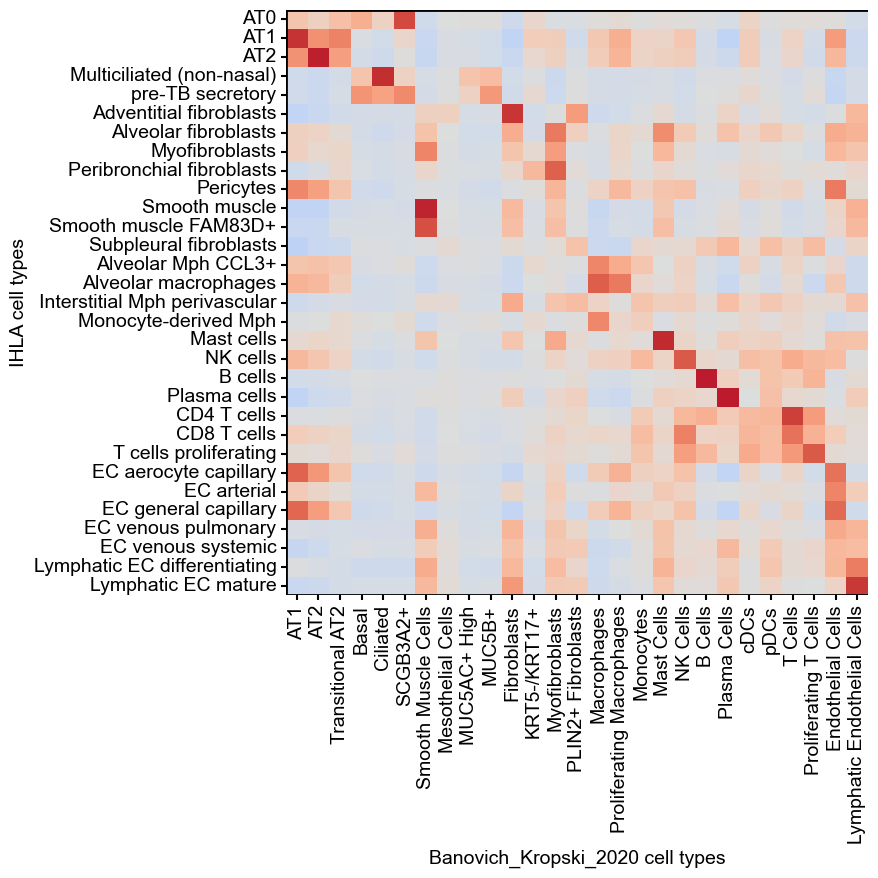

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,1, figsize = (9,9))
sns.heatmap(full_corr.loc[ann_finest_level_ct_order , Banovich_Kropski_2020_ct_order ],  cmap='coolwarm', center=0, vmin = -1, vmax = 1, cbar= None, ax = ax)


# Calculate the position and size of the heatmap in data coordinates
x0, y0 = ax.get_position().x0, ax.get_position().y0
width = ax.get_position().width
height = ax.get_position().height

# Add a rectangle patch to create a border around the heatmap
rect = patches.Rectangle(
    (0, 0),         # lower-left corner in data coordinates
    full_corr.shape[1],  # width (number of columns)
    full_corr.shape[0],  # height (number of rows)
    linewidth=2,
    edgecolor='black',
    facecolor='none'
)

# The coordinates here are in "data" units; add to heatmap axis
ax.add_patch(rect)



plt.title("")
plt.ylabel("IHLA cell types")
plt.xlabel("Banovich_Kropski_2020 cell types")
plt.tight_layout()
plt.savefig(os.path.join(save_dir,"hm_no_dendro.pdf"), bbox_inches = "tight", transparent = True)
plt.show()

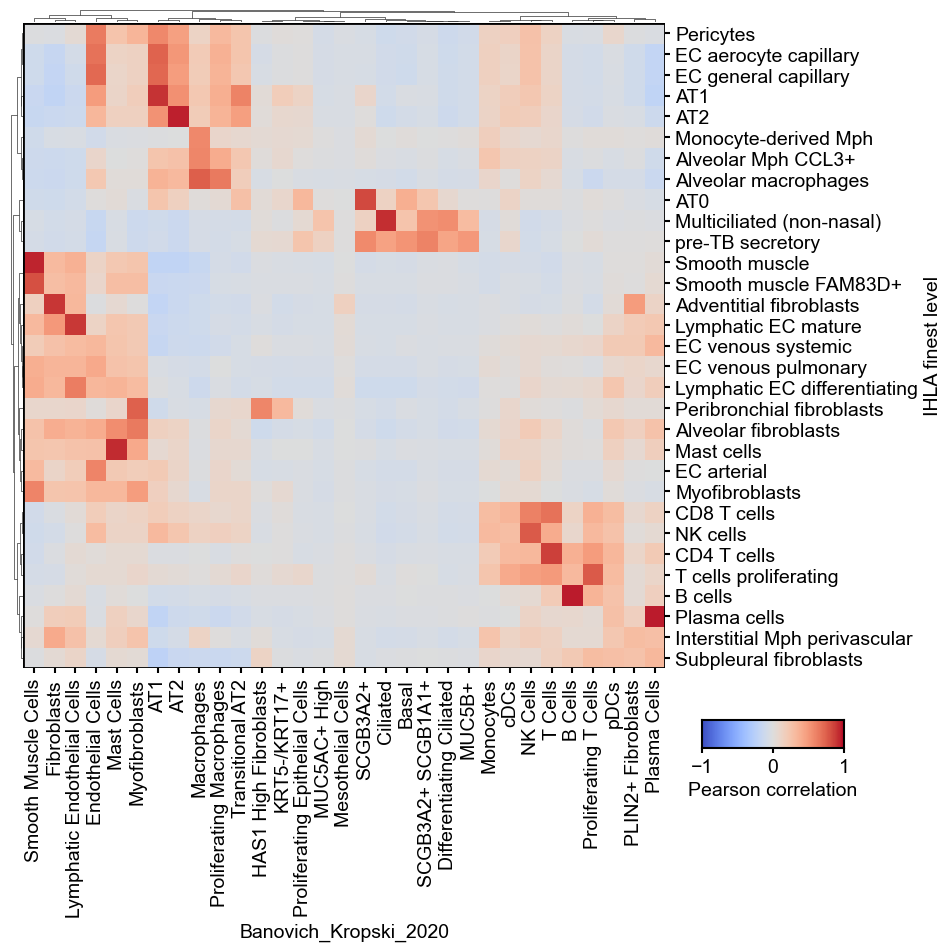

In [27]:
g = sns.clustermap(
    full_corr,
    method='ward',       # linkage method: 'single', 'complete', 'average', etc.
    metric='euclidean',   # distance metric: 'euclidean', 'correlation', etc.
    cmap='coolwarm',
    center=0,
    vmin = -1, vmax = 1,
    figsize=(9.5, 9.5),
    dendrogram_ratio=0.02,
    cbar_pos=(0.75, 0.20, 0.15, .03,),
    cbar_kws = {"orientation": "horizontal",
                "label":"Pearson correlation"}
              # optional: show correlation values
)

cbar_ax = g.cax  # the colorbar Axes instance

for spine in cbar_ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')
    #spine.set_linewidth(2)

ax = g.ax_heatmap
# Calculate the position and size of the heatmap in data coordinates
x0, y0 = ax.get_position().x0, ax.get_position().y0
width = ax.get_position().width
height = ax.get_position().height

# Add a rectangle patch to create a border around the heatmap
rect = patches.Rectangle(
    (0, 0),         # lower-left corner in data coordinates
    full_corr.shape[1],  # width (number of columns)
    full_corr.shape[0],  # height (number of rows)
    linewidth=2,
    edgecolor='black',
    facecolor='none'
)

# The coordinates here are in "data" units; add to heatmap axis
ax.add_patch(rect)

ax.set_xlabel("Banovich_Kropski_2020")
ax.set_ylabel("IHLA finest level")


plt.savefig(os.path.join(save_dir,"hm_dendro.pdf"), bbox_inches = "tight", transparent= True)